In [ ]:
# %pip uninstall -y pyiss
# %pip install "pyiss @ git+https://github.com/ArnaudMath/pyiss.git"


Found existing installation: pyiss 0.4.0
Uninstalling pyiss-0.4.0:
  Successfully uninstalled pyiss-0.4.0
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/ArnaudMath/pyiss.git to /private/var/folders/3p/2krh_m1510s37sjtv433wjh40000gn/T/pip-install-n8age8_z/pyiss_40089a69a1f24de1a220106662369c7f
  Running command git clone --filter=blob:none --quiet https://github.com/ArnaudMath/pyiss.git /private/var/folders/3p/2krh_m1510s37sjtv433wjh40000gn/T/pip-install-n8age8_z/pyiss_40089a69a1f24de1a220106662369c7f
  Resolved https://github.com/ArnaudMath/pyiss.git to commit 039b80a0ef52628ba9a4bb262b8f6671e2bbdee0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyiss: filename=pyiss-0.4.0-py3-none-any.whl size=20496 sha256=7fd9143e33e0c179ac3250b7c920b5918c5d307588dc7b67e4700a81f4df28f5
  Stored in directory: /private/var/folders/3p/2krh_m1510s37s

In [3]:
# # Local development path (skip this cell if you pip-installed pyiss)
# import sys
# from pathlib import Path

# root = Path("..").resolve()
# sys.path.insert(0, str(root / "src"))

In [4]:
import pyiss as iss

set1 = iss.infer_set("co-iss-n1823513381")
# set2 = iss.infer_set("co-iss-n1500059085")
# set3 = iss.infer_set("co-iss-w1540365932"), set4 = ...
set1

In [5]:
print("size:", set1.size)
print("available_filters:", set1.available_filters)
print("time_window:", set1.time_window)
print("duration_s:", set1.time_window.duration_s)

size: 3
available_filters: ['UV3', 'GRN', 'IR3']
time_window: TimeWindow(start=Timestamp('2015-10-14 10:25:26.342000+0000', tz='UTC'), end=Timestamp('2015-10-14 10:27:17.150000+0000', tz='UTC'))
duration_s: 110.808


In [6]:
set1.df

,opusid,time1,target,COISSfilter
0,co-iss-n1823513326,2015-10-14 10:25:26.342000+00:00,Enceladus,UV3
1,co-iss-n1823513381,2015-10-14 10:26:23.090000+00:00,Enceladus,GRN
2,co-iss-n1823513436,2015-10-14 10:27:17.150000+00:00,Enceladus,IR3


In [7]:
f0 = set1.available_filters[0]
print("example filter:", f0)

# Use filter() + metadata() to access observation details
print(set1.filter(f0).metadata("opusid", "time1", "target"))

example filter: UV3
               opusid                            time1     target
0  co-iss-n1823513326 2015-10-14 10:25:26.342000+00:00  Enceladus


In [8]:
# Here you can check if it is indeed a bounded set.
# It is a more elaborate version of df, but with more context:
# Row A shows the last images of the set before,
# and row Z shows the first images of the very next set
set1.diagnostic_window()

,_role,opusid,time1,target,COISSfilter,dt_prev_s,dt_next_s
0,A,co-iss-n1823513218,2015-10-14 10:23:39.151000+00:00,Enceladus,IR3,NaN,107.191
1,set,co-iss-n1823513326,2015-10-14 10:25:26.342000+00:00,Enceladus,UV3,107.191,56.748
2,set,co-iss-n1823513381,2015-10-14 10:26:23.090000+00:00,Enceladus,GRN,56.748,54.060
3,set,co-iss-n1823513436,2015-10-14 10:27:17.150000+00:00,Enceladus,IR3,54.060,142.191
4,Z,co-iss-n1823513579,2015-10-14 10:29:39.341000+00:00,Enceladus,UV3,142.191,NaN


In [9]:
set1.show()  # all previews

In [10]:
set1.show("UV3") # You can chose a filter of your liking


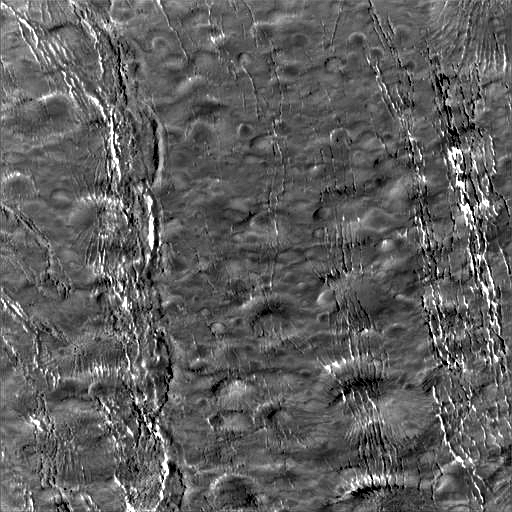

In [11]:
# Simple image ratio: divide one filter by another
pair1 = set1.pair("GRN", "IR3")
ratio = pair1.divide()
ratio.show()